# EXPERIMENT 4

# AIM

To implement a simple linear regression model, determine the best-fit line between a predictor and target variable, analyze residuals to evaluate linear regression assumptions, and study the effect of outliers on the regression model. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load Dataset
df = pd.read_csv("data.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(4), int6

In [4]:
display(df.describe())

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [5]:
# Check Missing Values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64


In [6]:
# Select Predictor and Target
X = df[["sqft_living"]]
y = df["price"]

# Remove missing values
data = pd.concat([X, y], axis=1).dropna()

X = data[["sqft_living"]]
y = data["price"]

print("Predictor:", X.columns[0])
print("Target:", y.name)
print("Final Dataset Shape:", X.shape)

Predictor: sqft_living
Target: price
Final Dataset Shape: (4600, 1)


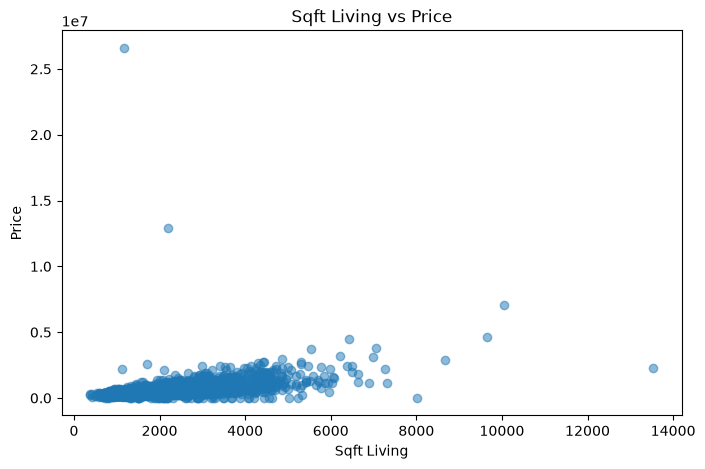

In [7]:
# Scatter Plot
plt.figure(figsize=(8, 5))

plt.scatter(X["sqft_living"], y, alpha=0.5)

plt.xlabel("Sqft Living")
plt.ylabel("Price")
plt.title("Sqft Living vs Price")

plt.show()

In [8]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 3220
Testing Samples: 1380


In [9]:
# Create and Train Linear Regression Model
model = LinearRegression()

model.fit(X_train, y_train)

slope = model.coef_[0]
intercept = model.intercept_

print("Slope:", slope)
print("Intercept:", intercept)

print(
    f"Regression Equation: Price = {intercept:.2f} + "
    f"({slope:.2f} × sqft_living)"
)

Slope: 270.1455024141993
Intercept: -31790.64064156881
Regression Equation: Price = -31790.64 + (270.15 × sqft_living)


In [10]:
# Generate Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

display(pd.DataFrame({
    "Actual Price": y_test.values[:10],
    "Predicted Price": y_test_pred[:10]
}))

,Actual Price,Predicted Price
0,5.440000e+05,362621.792883
1,0.000000e+00,508500.364187
2,1.712500e+06,762437.136456
3,3.650000e+05,562529.464670
4,2.750000e+05,432859.623511
5,6.250000e+05,730019.676166
6,4.530000e+05,540917.824477
7,3.000000e+05,532813.459404
8,4.179857e+05,527410.549356
9,6.725000e+05,538216.369452


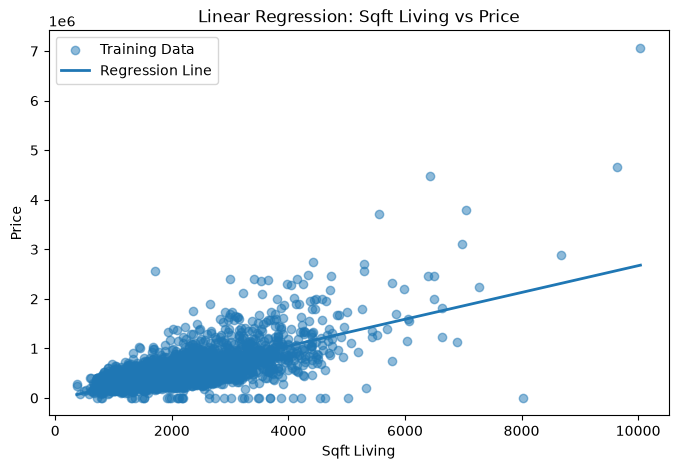

In [11]:
# Plot Regression Line
sorted_indices = np.argsort(X_train["sqft_living"].values)

plt.figure(figsize=(8, 5))

plt.scatter(
    X_train["sqft_living"],
    y_train,
    alpha=0.5,
    label="Training Data"
)

plt.plot(
    X_train["sqft_living"].values[sorted_indices],
    y_train_pred[sorted_indices],
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Sqft Living")
plt.ylabel("Price")
plt.title("Linear Regression: Sqft Living vs Price")
plt.legend()

plt.show()

In [12]:
# Model Evaluation
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Squared Error: 683873891465.4897
Root Mean Squared Error: 826966.6809887142
R² Score: 0.05339883218162034


In [13]:
# Calculate Residuals
residuals = y_test - y_test_pred

print("First 10 Residuals:")
display(residuals.head(10))

First 10 Residuals:


3683    181378.207117
4411   -508500.364187
2584    950062.863544
69     -197529.464670
1844   -157859.623511
33     -105019.676166
3085    -87917.824477
4034   -232813.459404
4469   -109424.835070
4578    134283.630548
Name: price, dtype: float64

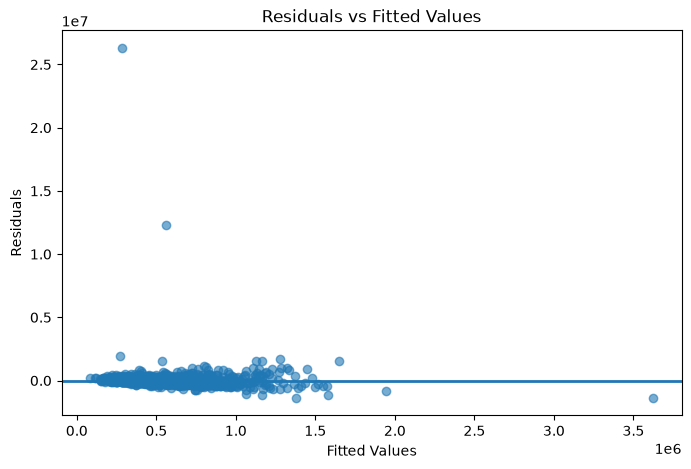

In [14]:
# Residual Plot
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linewidth=2
)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.show()

In [15]:
# Add 5 Artificial Outliers
X_train_outlier = X_train.reset_index(drop=True).copy()
y_train_outlier = y_train.reset_index(drop=True).copy()

outlier_X = pd.DataFrame({
    "sqft_living": [8000, 9000, 10000, 11000, 12000]
})

outlier_y = pd.Series(
    [3000000, 3500000, 4000000, 4500000, 5000000],
    name="price"
)

X_train_outlier = pd.concat(
    [X_train_outlier, outlier_X],
    ignore_index=True
)

y_train_outlier = pd.concat(
    [y_train_outlier, outlier_y],
    ignore_index=True
)

print("Original Training Samples:", len(X_train))
print("Training Samples With Outliers:", len(X_train_outlier))

Original Training Samples: 3220
Training Samples With Outliers: 3225


In [16]:
# Train Model With Outliers
model_outlier = LinearRegression()

model_outlier.fit(
    X_train_outlier,
    y_train_outlier
)

slope_outlier = model_outlier.coef_[0]
intercept_outlier = model_outlier.intercept_

print("Original Model")
print("Slope:", slope)
print("Intercept:", intercept)

print("\nModel With Outliers")
print("Slope:", slope_outlier)
print("Intercept:", intercept_outlier)

Original Model
Slope: 270.1455024141993
Intercept: -31790.64064156881

Model With Outliers
Slope: 286.79811976166235
Intercept: -65538.1719805419


In [17]:
# Compare Regression Parameters
comparison = pd.DataFrame({
    "Parameter": ["Slope", "Intercept"],
    "Original Model": [slope, intercept],
    "With Outliers": [slope_outlier, intercept_outlier]
})

display(comparison)

,Parameter,Original Model,With Outliers
0,Slope,270.145502,286.798120
1,Intercept,-31790.640642,-65538.171981


/opt/miniconda3/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


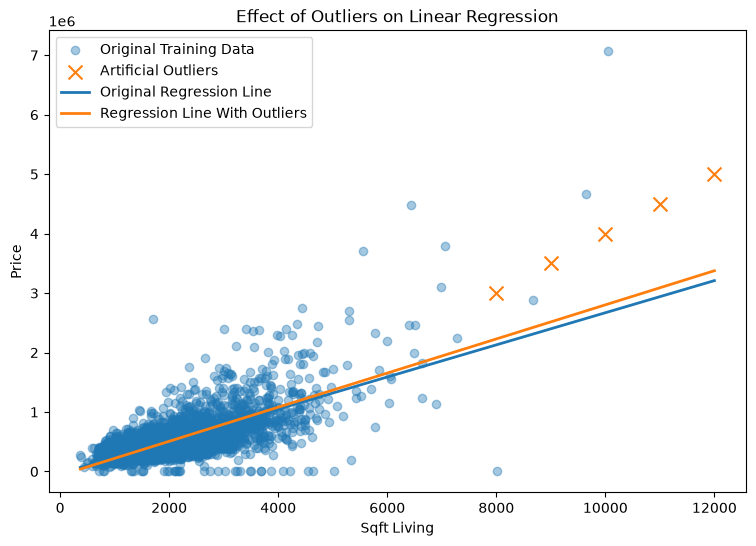

In [18]:
# Plot Effect of Outliers
x_range = np.linspace(
    X_train["sqft_living"].min(),
    X_train_outlier["sqft_living"].max(),
    300
).reshape(-1, 1)

original_line = model.predict(x_range)
outlier_line = model_outlier.predict(x_range)

plt.figure(figsize=(9, 6))

plt.scatter(
    X_train["sqft_living"],
    y_train,
    alpha=0.4,
    label="Original Training Data"
)

plt.scatter(
    outlier_X["sqft_living"],
    outlier_y,
    marker="x",
    s=100,
    label="Artificial Outliers"
)

plt.plot(
    x_range,
    original_line,
    linewidth=2,
    label="Original Regression Line"
)

plt.plot(
    x_range,
    outlier_line,
    linewidth=2,
    label="Regression Line With Outliers"
)

plt.xlabel("Sqft Living")
plt.ylabel("Price")
plt.title("Effect of Outliers on Linear Regression")
plt.legend()

plt.show()

In [19]:
# Performance Comparison
y_test_pred_original = model.predict(X_test)
y_test_pred_outlier = model_outlier.predict(X_test)

original_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred_original)
)

outlier_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred_outlier)
)

original_r2 = r2_score(y_test, y_test_pred_original)
outlier_r2 = r2_score(y_test, y_test_pred_outlier)

performance = pd.DataFrame({
    "Model": [
        "Original Model",
        "Model With Outliers"
    ],
    "RMSE": [
        original_rmse,
        outlier_rmse
    ],
    "R² Score": [
        original_r2,
        outlier_r2
    ]
})

display(performance)

,Model,RMSE,R² Score
0,Original Model,826966.680989,0.053399
1,Model With Outliers,828216.178815,0.050536


# OBSERVATION

- The linear regression model was successfully fitted using `sqft_living` as the predictor and `price` as the target.
- A positive relationship was observed between living area and house price.
- Residuals were analyzed using a residual-versus-fitted-values plot.
- The residual plot was examined for curvature, funnel-shaped patterns, and unusual observations.
- Artificial outliers caused changes in the slope and intercept of the regression line.
- This demonstrates that ordinary least-squares linear regression is sensitive to extreme observations.

# CONCLUSION

Simple linear regression was successfully implemented using `sqft_living` to predict `price`. The slope, intercept, predictions, residuals, RMSE, and R² score were calculated.

Residual analysis was performed to examine the assumptions of linear regression. Artificial outliers were then introduced into the training data, demonstrating their influence on the regression parameters and model performance.

Therefore, `sqft_living` is a useful predictor of house price, although additional features could be used to improve the prediction performance.